<a href="https://colab.research.google.com/github/juhee0528-lang/git/blob/main/lending_club_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 라이브버리

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# 업로드된 CSV 파일 불러오기
train = pd.read_csv("train.csv")
val = pd.read_csv("validation.csv")

print("Train shape:", train.shape)
print("Validation shape:", val.shape)

print("\nTrain default 분포")
print(train["default"].value_counts())

print("\n주요 컬럼")
print(train[["default", "int_rate", "treasury_yield_3y"]].head())

Train shape: (310778, 66)
Validation shape: (268623, 66)

Train default 분포
default
0    155389
1    155389
Name: count, dtype: int64

주요 컬럼
   default  int_rate  treasury_yield_3y
0        0      6.24           1.013333
1        1     17.09           1.807619
2        1     17.77           0.577000
3        0      6.49           0.971905
4        0     11.47           0.896500


2. 전처리

현재 데이터는 int_rate와 treasury_yield_3y가 6.24, 4.35와 같은 퍼센트 단위일 가능성이 높으므로 수익률 계산 시 100으로 나눕니다.

In [32]:
TARGET_COL = "default"
INTEREST_COL = "int_rate"
TREASURY_COL = "treasury_yield_3y"

In [33]:
def prepare_data(
    train_df,
    val_df,
    target_col="default",
    interest_col="int_rate",
    treasury_col="treasury_yield_3y"
):
    train_data = train_df.copy()
    val_data = val_df.copy()

    required_cols = [
        target_col,
        interest_col,
        treasury_col
    ]

    for col in required_cols:
        if col not in train_data.columns:
            raise ValueError(
                f"train 데이터에 '{col}' 컬럼이 없습니다."
            )

        if col not in val_data.columns:
            raise ValueError(
                f"validation 데이터에 '{col}' 컬럼이 없습니다."
            )

    # target 결측치가 있는 행 제거
    train_data = train_data.dropna(
        subset=[target_col]
    ).copy()

    val_data = val_data.dropna(
        subset=[
            target_col,
            interest_col,
            treasury_col
        ]
    ).copy()

    # target을 정수형으로 변환
    train_data[target_col] = (
        train_data[target_col].astype(int)
    )

    val_data[target_col] = (
        val_data[target_col].astype(int)
    )

    # 독립변수와 종속변수 분리
    X_train = train_data.drop(
        columns=[target_col]
    ).copy()

    X_val = val_data.drop(
        columns=[target_col]
    ).copy()

    y_train = train_data[target_col].copy()
    y_val = val_data[target_col].copy()

    # bool 컬럼을 0과 1로 변환
    bool_cols = X_train.select_dtypes(
        include=["bool"]
    ).columns.tolist()

    for col in bool_cols:
        X_train[col] = X_train[col].astype(np.int8)
        X_val[col] = X_val[col].astype(np.int8)

    # 모든 컬럼을 숫자형으로 변환
    for col in X_train.columns:
        X_train[col] = pd.to_numeric(
            X_train[col],
            errors="coerce"
        )

        X_val[col] = pd.to_numeric(
            X_val[col],
            errors="coerce"
        )

    # 무한대 값을 결측값으로 변환
    X_train = X_train.replace(
        [np.inf, -np.inf],
        np.nan
    )

    X_val = X_val.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # 샤프레이시오 계산에 사용할 validation 자료
    val_interest_rate = pd.to_numeric(
        val_data[interest_col],
        errors="coerce"
    ).to_numpy(dtype=float)

    val_treasury_rate = pd.to_numeric(
        val_data[treasury_col],
        errors="coerce"
    ).to_numpy(dtype=float)

    # 6.24, 17.09 형태를 0.0624, 0.1709로 변환
    if np.nanmedian(val_interest_rate) > 1:
        val_interest_rate = val_interest_rate / 100

    if np.nanmedian(val_treasury_rate) > 1:
        val_treasury_rate = val_treasury_rate / 100

    print("변환된 bool 컬럼 개수:", len(bool_cols))
    print(
        "남은 bool 컬럼:",
        X_train.select_dtypes(
            include=["bool"]
        ).columns.tolist()
    )

    return (
        X_train,
        y_train,
        X_val,
        y_val,
        val_interest_rate,
        val_treasury_rate,
        val_data
    )

In [34]:
(
    X_train,
    y_train,
    X_val,
    y_val,
    val_interest_rate,
    val_treasury_rate,
    val_clean
) = prepare_data(
    train_df=train,
    val_df=val,
    target_col=TARGET_COL,
    interest_col=INTEREST_COL,
    treasury_col=TREASURY_COL
)

변환된 bool 컬럼 개수: 11
남은 bool 컬럼: []


In [35]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("Train 부도율:", round(y_train.mean(), 4))
print("Validation 부도율:", round(y_val.mean(), 4))

print(
    "Validation 평균 이자율:",
    round(val_interest_rate.mean(), 4)
)

print(
    "Validation 평균 국채수익률:",
    round(val_treasury_rate.mean(), 4)
)

X_train shape: (310778, 65)
X_val shape: (268623, 65)
Train 부도율: 0.5
Validation 부도율: 0.1928
Validation 평균 이자율: 0.1313
Validation 평균 국채수익률: 0.0123


3. 부도 예측모델 학습

In [36]:
model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=31,
                min_samples_leaf=30,
                l2_regularization=1.0,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=20
            )
        )
    ]
)

In [37]:
model.fit(
    X_train,
    y_train
)

print("모델 학습 완료")

모델 학습 완료


4. Validation 부도확률 예측

In [38]:
val_default_probability = model.predict_proba(
    X_val
)[:, 1]

val_auc = roc_auc_score(
    y_val,
    val_default_probability
)

print(
    "Validation ROC-AUC:",
    round(val_auc, 4)
)

Validation ROC-AUC: 0.7243


In [39]:
val_pred_05 = (
    val_default_probability >= 0.5
).astype(int)

print(
    classification_report(
        y_val,
        val_pred_05,
        digits=4
    )
)

print("Confusion matrix")
print(
    confusion_matrix(
        y_val,
        val_pred_05
    )
)

              precision    recall  f1-score   support

           0     0.8942    0.6451    0.7495    216826
           1     0.3141    0.6804    0.4298     51797

    accuracy                         0.6519    268623
   macro avg     0.6041    0.6627    0.5896    268623
weighted avg     0.7823    0.6519    0.6878    268623

Confusion matrix
[[139865  76961]
 [ 16556  35241]]


5. Threshold별 샤프레이시오 계산 함수

아래 함수는 세 가지 수익률 방식을 제공합니다.

interest: 요청한 방식. 투자수익률을 이자율로 계산

realized: 실제 부도를 반영. 정상 대출은 이자율, 부도 대출은 손실

expected: 모델이 예측한 부도확률을 반영한 기대수익률

In [40]:
def calculate_threshold_sharpe(
    y_true,
    default_probability,
    interest_rate,
    treasury_rate,
    thresholds=None,
    return_mode="interest",
    loss_given_default=1.0,
    recovery_rate=0.0,
    min_investments=100,
    ddof=1
):
    """
    Threshold별 투자 포트폴리오와 Sharpe Ratio를 계산합니다.

    투자 조건
    ---------
    예측 부도확률 <= threshold

    return_mode
    -----------
    interest:
        투자수익률 = 대출 이자율

    realized:
        정상 대출 수익률 = 이자율
        부도 대출 수익률 = -(1 - 회수율)

    expected:
        예측 부도확률을 이용한 기대수익률
    """

    if thresholds is None:
        thresholds = np.arange(
            0.01,
            0.81,
            0.01
        )

    y_true = np.asarray(
        y_true,
        dtype=int
    )

    default_probability = np.asarray(
        default_probability,
        dtype=float
    )

    interest_rate = np.asarray(
        interest_rate,
        dtype=float
    )

    # 국채수익률이 하나의 값이면 전체 대출에 동일하게 적용
    if np.isscalar(treasury_rate):
        treasury_rate = np.full(
            len(y_true),
            float(treasury_rate)
        )

    else:
        treasury_rate = np.asarray(
            treasury_rate,
            dtype=float
        )

    lengths = [
        len(y_true),
        len(default_probability),
        len(interest_rate),
        len(treasury_rate)
    ]

    if len(set(lengths)) != 1:
        raise ValueError(
            "입력 데이터들의 길이가 모두 같아야 합니다."
        )

    results = []

    for threshold in thresholds:

        # 부도확률이 threshold 이하인 대출에 투자
        selected = (
            default_probability <= threshold
        )

        n_investments = int(selected.sum())
        investment_ratio = float(selected.mean())

        if n_investments < min_investments:
            results.append({
                "threshold": threshold,
                "sharpe_ratio": np.nan,
                "n_investments": n_investments,
                "investment_ratio": investment_ratio,
                "actual_default_rate": np.nan,
                "mean_predicted_default_probability": np.nan,
                "mean_interest_rate": np.nan,
                "mean_treasury_rate": np.nan,
                "mean_portfolio_return": np.nan,
                "mean_excess_return": np.nan,
                "excess_return_std": np.nan
            })

            continue

        selected_y = y_true[selected]

        selected_probability = (
            default_probability[selected]
        )

        selected_interest = (
            interest_rate[selected]
        )

        selected_treasury = (
            treasury_rate[selected]
        )

        # 요청한 방식: 수익률을 이자율로 사용
        if return_mode == "interest":
            portfolio_return = selected_interest

        # 실제 부도 결과 반영
        elif return_mode == "realized":

            default_loss = -(
                loss_given_default
                * (1 - recovery_rate)
            )

            portfolio_return = np.where(
                selected_y == 0,
                selected_interest,
                default_loss
            )

        # 예측 부도확률을 이용한 기대수익률
        elif return_mode == "expected":

            default_loss = (
                loss_given_default
                * (1 - recovery_rate)
            )

            portfolio_return = (
                (1 - selected_probability)
                * selected_interest
                - selected_probability
                * default_loss
            )

        else:
            raise ValueError(
                "return_mode는 'interest', 'realized', "
                "'expected' 중 하나여야 합니다."
            )

        # 각 대출의 초과수익률
        excess_return = (
            portfolio_return
            - selected_treasury
        )

        mean_excess_return = np.mean(
            excess_return
        )

        excess_return_std = np.std(
            excess_return,
            ddof=ddof
        )

        if (
            not np.isfinite(excess_return_std)
            or excess_return_std <= 0
        ):
            sharpe_ratio = np.nan

        else:
            sharpe_ratio = (
                mean_excess_return
                / excess_return_std
            )

        results.append({
            "threshold": threshold,
            "sharpe_ratio": sharpe_ratio,
            "n_investments": n_investments,
            "investment_ratio": investment_ratio,
            "actual_default_rate": selected_y.mean(),
            "mean_predicted_default_probability":
                selected_probability.mean(),
            "mean_interest_rate": selected_interest.mean(),
            "mean_treasury_rate": selected_treasury.mean(),
            "mean_portfolio_return": portfolio_return.mean(),
            "mean_excess_return": mean_excess_return,
            "excess_return_std": excess_return_std
        })

    return pd.DataFrame(results)

6. 요청한 방식의 샤프레이시오 계산

투자수익률을 대출 이자율로 두고, 각 행의 treasury_yield_3y를 벤치마크로 사용합니다.

threshold는 0.01부터 0.80까지 0.01씩 증가시킵니다.

In [41]:
thresholds = np.arange(
    0.01,
    0.81,
    0.01
)

interest_results = calculate_threshold_sharpe(
    y_true=y_val,
    default_probability=val_default_probability,
    interest_rate=val_interest_rate,
    treasury_rate=val_treasury_rate,
    thresholds=thresholds,
    return_mode="interest",
    min_investments=100
)

In [42]:
valid_interest_results = interest_results.dropna(
    subset=["sharpe_ratio"]
).copy()

if valid_interest_results.empty:
    raise ValueError(
        "계산 가능한 Sharpe Ratio가 없습니다. "
        "min_investments 값을 낮춰보세요."
    )

best_interest_index = valid_interest_results[
    "sharpe_ratio"
].idxmax()

best_interest_result = valid_interest_results.loc[
    best_interest_index
]

print("요청 방식의 최적 결과")
print(best_interest_result)

요청 방식의 최적 결과
threshold                                0.060000
sharpe_ratio                             5.045012
n_investments                         1041.000000
investment_ratio                         0.003875
actual_default_rate                      0.011527
mean_predicted_default_probability       0.051320
mean_interest_rate                       0.057443
mean_treasury_rate                       0.011158
mean_portfolio_return                    0.057443
mean_excess_return                       0.046285
excess_return_std                        0.009174
Name: 5, dtype: float64


주요 결과

In [43]:
print(
    "최적 threshold:",
    round(best_interest_result["threshold"], 4)
)

print(
    "최대 Sharpe Ratio:",
    round(best_interest_result["sharpe_ratio"], 4)
)

print(
    "투자 건수:",
    int(best_interest_result["n_investments"])
)

print(
    "투자 비율:",
    round(best_interest_result["investment_ratio"], 4)
)

print(
    "선택 대출 실제 부도율:",
    round(best_interest_result["actual_default_rate"], 4)
)

print(
    "평균 이자율:",
    round(best_interest_result["mean_interest_rate"], 4)
)

print(
    "평균 국채수익률:",
    round(best_interest_result["mean_treasury_rate"], 4)
)

print(
    "평균 초과수익률:",
    round(best_interest_result["mean_excess_return"], 4)
)

최적 threshold: 0.06
최대 Sharpe Ratio: 5.045
투자 건수: 1041
투자 비율: 0.0039
선택 대출 실제 부도율: 0.0115
평균 이자율: 0.0574
평균 국채수익률: 0.0112
평균 초과수익률: 0.0463


7. Threshold별 샤프레이시오 그래프

/tmp/ipykernel_1005/2149962424.py:42: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2149962424.py:42: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2149962424.py:42: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2149962424.py:42: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2149962424.py:42: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2149962424.py:42: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2149962424.py:42: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layo

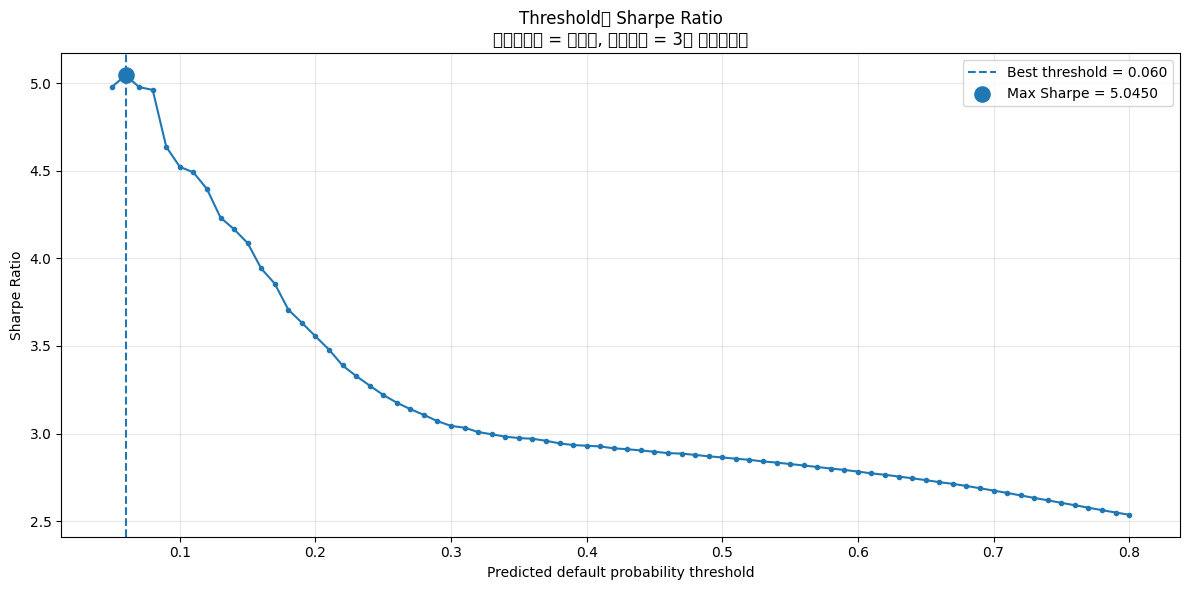

In [44]:
best_threshold = best_interest_result[
    "threshold"
]

best_sharpe = best_interest_result[
    "sharpe_ratio"
]

plt.figure(figsize=(12, 6))

plt.plot(
    valid_interest_results["threshold"],
    valid_interest_results["sharpe_ratio"],
    marker="o",
    markersize=3,
    linewidth=1.5
)

plt.axvline(
    x=best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.3f}"
)

plt.scatter(
    best_threshold,
    best_sharpe,
    s=120,
    zorder=5,
    label=f"Max Sharpe = {best_sharpe:.4f}"
)

plt.xlabel("Predicted default probability threshold")
plt.ylabel("Sharpe Ratio")
plt.title(
    "Threshold별 Sharpe Ratio\n"
    "투자수익률 = 이자율, 벤치마크 = 3년 국채수익률"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

8. 투자 건수와 샤프레이시오 같이 그리기

/tmp/ipykernel_1005/2445229416.py:43: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1005/2445229416.py:43: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1005/2445229416.py:43: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1005/2445229416.py:43: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1005/2445229416.py:43: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1005/2445229416.py:43: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from fo

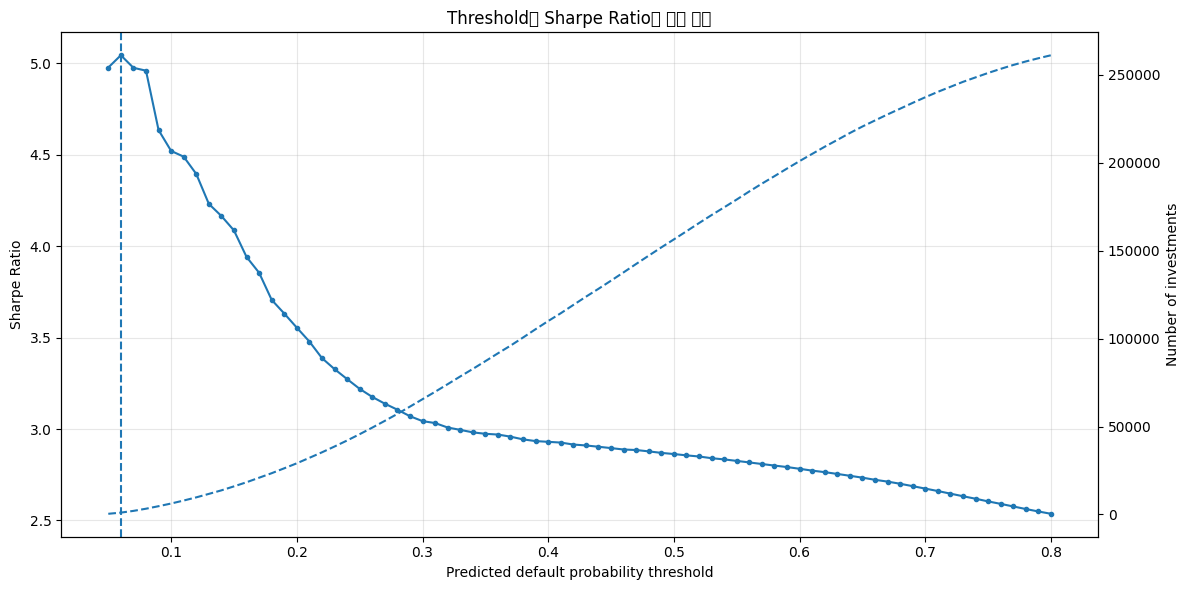

In [45]:
fig, ax1 = plt.subplots(
    figsize=(12, 6)
)

ax1.plot(
    valid_interest_results["threshold"],
    valid_interest_results["sharpe_ratio"],
    marker="o",
    markersize=3
)

ax1.axvline(
    best_threshold,
    linestyle="--"
)

ax1.set_xlabel(
    "Predicted default probability threshold"
)

ax1.set_ylabel(
    "Sharpe Ratio"
)

ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    valid_interest_results["threshold"],
    valid_interest_results["n_investments"],
    linestyle="--"
)

ax2.set_ylabel(
    "Number of investments"
)

plt.title(
    "Threshold별 Sharpe Ratio와 투자 건수"
)

fig.tight_layout()
plt.show()

9. 실제 부도손실을 반영한 샤프레이시오


요청한 방식은 부도난 대출에도 이자율 수익이 발생한 것으로 계산된다는 한계가 있습니다.

따라서 실제 평가에서는 정상 상환이면 이자수익, 부도이면 원금손실을 적용한 결과도 함께 보는 것이 좋습니다.

In [46]:
realized_results = calculate_threshold_sharpe(
    y_true=y_val,
    default_probability=val_default_probability,
    interest_rate=val_interest_rate,
    treasury_rate=val_treasury_rate,
    thresholds=thresholds,
    return_mode="realized",

    # 부도 시 원금손실률
    loss_given_default=1.0,

    # 회수율 0% 가정
    recovery_rate=0.0,

    min_investments=100
)

In [47]:
valid_realized_results = realized_results.dropna(
    subset=["sharpe_ratio"]
).copy()

best_realized_index = valid_realized_results[
    "sharpe_ratio"
].idxmax()

best_realized_result = valid_realized_results.loc[
    best_realized_index
]

print("실제 부도손실 반영 결과")
print(best_realized_result)

실제 부도손실 반영 결과
threshold                               0.050000
sharpe_ratio                            0.514520
n_investments                         371.000000
investment_ratio                        0.001381
actual_default_rate                     0.005391
mean_predicted_default_probability      0.043987
mean_interest_rate                      0.056963
mean_treasury_rate                      0.010974
mean_portfolio_return                   0.051249
mean_excess_return                      0.040275
excess_return_std                       0.078277
Name: 4, dtype: float64


10. 요청 방식과 실제 부도반영 방식 비교 그래프

/tmp/ipykernel_1005/2541488767.py:29: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2541488767.py:29: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2541488767.py:29: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2541488767.py:29: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2541488767.py:29: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2541488767.py:29: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1005/2541488767.py:29: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_

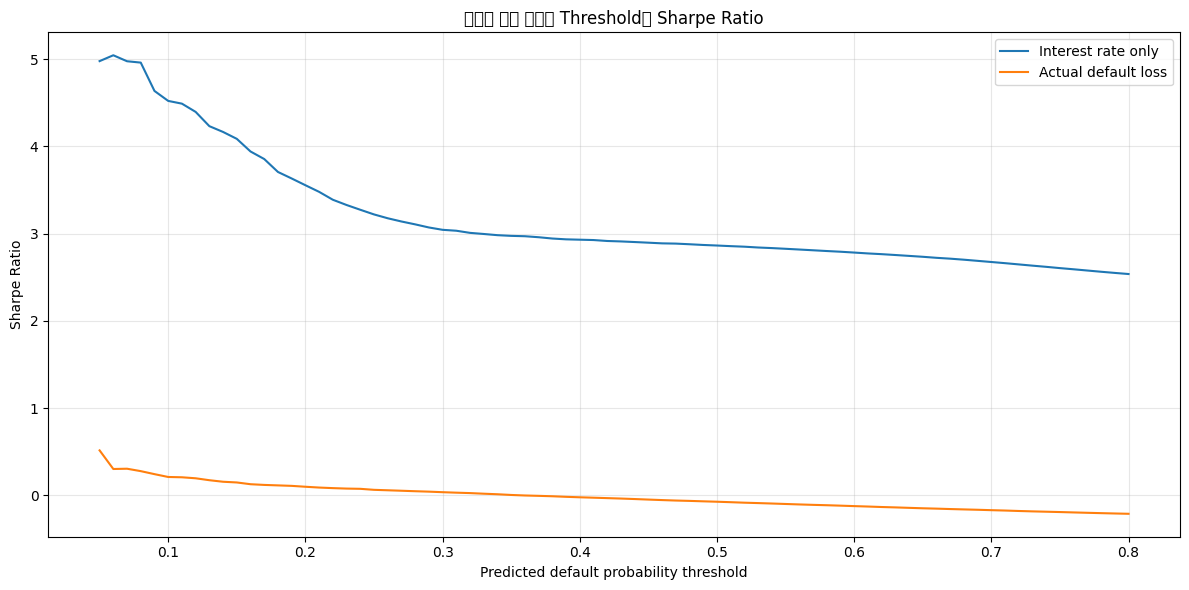

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(
    valid_interest_results["threshold"],
    valid_interest_results["sharpe_ratio"],
    label="Interest rate only"
)

plt.plot(
    valid_realized_results["threshold"],
    valid_realized_results["sharpe_ratio"],
    label="Actual default loss"
)

plt.xlabel(
    "Predicted default probability threshold"
)

plt.ylabel(
    "Sharpe Ratio"
)

plt.title(
    "수익률 계산 방법별 Threshold와 Sharpe Ratio"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

11. 최적 Threshold의 투자 대상 추출

실제 부도손실을 반영한 최적 threshold를 최종 투자 기준으로 사용

In [49]:
final_threshold = best_realized_result[
    "threshold"
]

val_result = val_clean.copy()

val_result[
    "pred_default_probability"
] = val_default_probability

val_result[
    "investment_selected"
] = (
    val_result["pred_default_probability"]
    <= final_threshold
)

selected_loans = val_result[
    val_result["investment_selected"]
].copy()

In [50]:
print(
    "최종 threshold:",
    round(final_threshold, 4)
)

print(
    "전체 Validation 대출 건수:",
    len(val_result)
)

print(
    "선택된 투자 건수:",
    len(selected_loans)
)

print(
    "투자 비율:",
    round(
        len(selected_loans) / len(val_result),
        4
    )
)

print(
    "선택된 대출의 실제 부도율:",
    round(
        selected_loans["default"].mean(),
        4
    )
)

print(
    "선택된 대출의 평균 이자율:",
    round(
        selected_loans["int_rate"].mean(),
        4
    )
)

최종 threshold: 0.05
전체 Validation 대출 건수: 268623
선택된 투자 건수: 371
투자 비율: 0.0014
선택된 대출의 실제 부도율: 0.0054
선택된 대출의 평균 이자율: 5.6963


투자 대상 확인

In [51]:
selected_loans[
    [
        "int_rate",
        "treasury_yield_3y",
        "default",
        "pred_default_probability",
        "investment_selected"
    ]
].sort_values(
    "pred_default_probability"
).head(20)

,int_rate,treasury_yield_3y,default,pred_default_probability,investment_selected
4207,5.32,1.585652,0,0.027441,True
123022,6.03,0.395909,0,0.028043,True
231844,8.46,0.218000,0,0.028999,True
48907,5.32,1.807619,0,0.029688,True
98086,5.32,0.860455,0,0.030337,True
51696,5.32,1.038182,0,0.031758,True
151635,5.31,2.657273,0,0.031777,True
246506,5.32,1.442105,0,0.032074,True
39894,6.03,0.685238,0,0.032126,True
182488,5.32,0.926667,0,0.032257,True
